In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import matplotlib.pyplot as plt
import utils.helpers as hlp
from samplers.linear_models import BayesianRegression
from utils.evaluation import ComputeAccuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sampling with the Wisconsin Breast Cancer data  
## Load the data

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

## Preprocessing

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

In [4]:
print(f"Training data contains {X_train.shape[0]} observations\n" 
      f"Test data contains {X_test.shape[0]} observations\n"
      f"Dimension: {X_train.shape[1]}")

Training data contains 398 observations
Test data contains 171 observations
Dimension: 31


## Set the boundary condition to select from $\ell_2$-ball prior

In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)
beta_hat = clf.coef_.flatten()
lp = 2 
s = 0.9 * np.linalg.norm(beta_hat, ord=lp)
print("||beta_hat||_{} = {:.4f}, s = {:.4f}"\
    .format(lp, np.linalg.norm(beta_hat, ord=lp), s))

||beta_hat||_2 = 3.3844, s = 3.0460


In [6]:
# lp=2
# dim = X_train.shape[1]
# s = np.sqrt(dim)

## Sample the posterior using MySGLD algorithm

In [7]:
seed = 42
model = BayesianRegression(
    X=X_train, y=y_train, type='logistic',
    N=400, batch_size=10, lp=lp, s=s, 
    eta=5e-4, gamma=1e-3, 
    seed=seed
)
chain = model.sample_parameters(
    method='mysgld', iterations=500,
    burn_in=0, eta_decay=False
)

  1%|          | 4/500 [00:00<00:13, 37.59it/s]

Iteration 1/500, eta=0.0005


100%|██████████| 500/500 [00:16<00:00, 31.16it/s]


In [ ]:
chain.shape

In [ ]:
def compute_running_accuracy(chain, X, y):
    n_iterations, dim, n_samples = chain.shape 
    mean_accuracy = []
    for k in range(n_iterations):
        iter_samples = chain[k, :, :]
        z = np.dot(X, iter_samples)
        probs = hlp.sigmoid(z)
        preds = (probs >= 0.5).astype(int)
        correct = (preds == y[:, np.newaxis])
        sample_accuracies = np.mean(correct, axis=0)
        mean_accuracy.append(np.mean(sample_accuracies))
    return mean_accuracy

In [ ]:
r_acc = compute_running_accuracy(chain, X_train, y_train)
plt.plot(r_acc)

In [ ]:
def compute_cumulative_accuracy(chain, X, y):
    n_iterations, dim, n_samples = chain.shape 
    cum_accuracy = []
    
    # We maintain a running sum of the weights to compute the mean weight
    # running_beta_sum shape will be (dim, n_samples)
    running_beta_sum = np.zeros((dim, n_samples))
    
    for k in range(n_iterations):
        # Update running sum
        running_beta_sum += chain[k, :, :]
        
        # Calculate the "Posterior Mean" weights at step k
        current_beta_mean = running_beta_sum / (k + 1)
        
        # Predict using the average weights
        z = np.dot(X, current_beta_mean)
        probs = hlp.sigmoid(z)
        preds = (probs >= 0.5).astype(int)
        
        # Accuracy of the average model
        correct = (preds == y[:, np.newaxis])
        cum_accuracy.append(np.mean(correct))
        
    return cum_accuracy

# Plot this instead
r_acc_cum = compute_cumulative_accuracy(chain, X_train, y_train)
plt.plot(r_acc_cum)
plt.title("Cumulative Mean Accuracy (Convergence of Posterior Mean)")

In [8]:
metric = ComputeAccuracy(X=X_train, y=y_train)
acc_matrix=metric.compute_accuracy(chain)
mean_acc = np.mean(acc_matrix, axis=1)
std_acc = np.std(acc_matrix, axis=1)

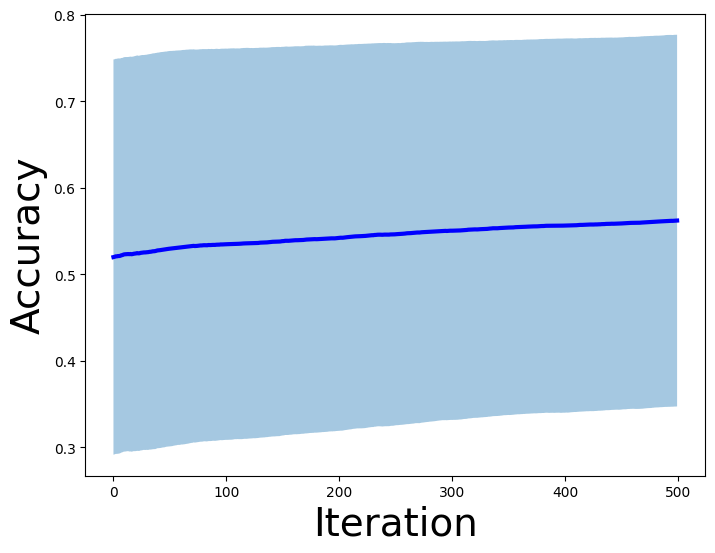

In [9]:
plt.figure(figsize=(8,6))
plt.plot(mean_acc, 'b-',linewidth=3)
plt.fill_between(
    range(len(mean_acc)), 
    mean_acc-std_acc, 
    mean_acc+std_acc, 
    alpha=0.4
)
plt.xlabel("Iteration", fontsize=28)
plt.ylabel("Accuracy", fontsize=28)
plt.show()

In [ ]:
metric = ComputeAccuracy(X=X_test, y=y_test)
acc=metric.compute_accuracy(chain)
stds = np.std(acc)
plt.figure(figsize=(8,6))
plt.plot(acc, linewidth=3, color='blue')
plt.fill_between(range(len(acc)), acc-stds, acc+stds, alpha=0.4)
plt.xlabel("Iteration", fontsize=28)
plt.ylabel("Accuracy", fontsize=28)
plt.show()

In [ ]:
def particle_accuracy_stats(chain, X, y):
    chain = np.asarray(chain)
    y = np.asarray(y).astype(int)
    T, dim, N = chain.shape 
    mean_acc = np.zeros(T)
    std_acc = np.zeros(T)
    for t in range(T):
        accs = []
        for n in range(N):
            theta = chain[t]
            probs = 1.0 / (1.0 + np.exp(-(X @ theta)))
            y_pred = (probs >= 0.5).astype(int)
            accs.append((y_pred == y[:,None]).mean(axis=0))
        accs = np.array(accs)
        mean_acc[t] = accs.mean()
        std_acc[t] = accs.std()
    return mean_acc, std_acc

In [ ]:
mean_acc, std_acc = particle_accuracy_stats(chain, X_train, y_train)
plt.figure(figsize=(8,6))
plt.plot(mean_acc, linewidth=3)
plt.fill_between(
    range(len(mean_acc)),
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.3
)